In [1]:
!pip install umap-learn hdbscan dateparser spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.5 MB/s  0:00:00m0:00:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import shutil
import os, re, string, time
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm import tqdm

from collections import Counter

import dateparser
from dateparser.search import search_dates

import spacy
nlp = spacy.load("en_core_web_sm")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.utils import resample

import umap
import hdbscan
import pandas as pd


/opt/anaconda3/envs/vis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
input_path = f"/Users/athmiha/Desktop/final report/train_clusters.csv"

df = pd.read_csv(input_path)
display(df.head(10))
print(df.shape)


,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,motorcycle,taxi,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster
0,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1082
1,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,1082
2,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,1082
3,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1082
4,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,1082
5,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,0,-1
6,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,-1
7,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,1,0,1082
8,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,1,1082
9,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,1,0,1082


(275184, 88)


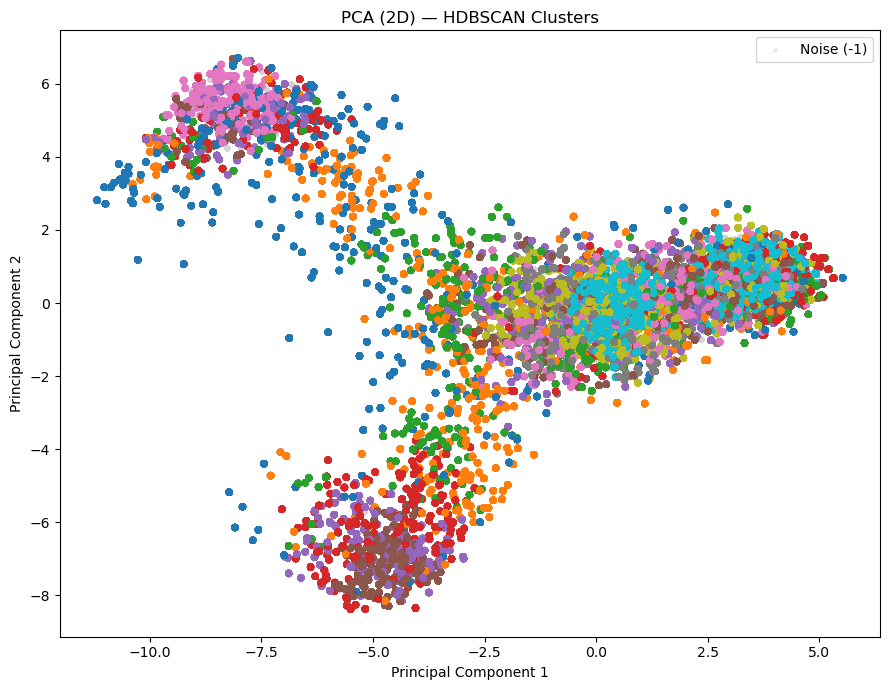

In [ ]:
cluster_col = "cluster"
exclude_cols = {"start_interval", "entries", "excluded_roadway_entries", cluster_col}


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [c for c in numeric_cols if c not in exclude_cols]
if len(feature_cols) == 0:
    raise ValueError("No numeric feature columns found for PCA (after exclusions).")


X = df[feature_cols].dropna(axis=0, how="any")
valid_idx = X.index

X_scaled = StandardScaler().fit_transform(X.values)
X_pca = PCA(n_components=2, random_state=0).fit_transform(X_scaled)

labels = pd.to_numeric(df.loc[valid_idx, cluster_col], errors="coerce").fillna(-1).astype(int).values

plt.figure(figsize=(9, 7))
noise_mask = labels == -1

if noise_mask.any():
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                s=10, alpha=0.35, color="lightgray", label="Noise (-1)")


plt.scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
            c=labels[~noise_mask], s=18, alpha=0.85, cmap="tab10")

plt.title("PCA (2D) — HDBSCAN Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=0.8, loc="best")
plt.tight_layout()
plt.show()


/var/folders/p1/cwzgr9lj7_5ct_l3lyn4cd3r0000gn/T/ipykernel_6664/3360541779.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(markerscale=1.0, loc="best", fontsize=9, frameon=True)
/var/folders/p1/cwzgr9lj7_5ct_l3lyn4cd3r0000gn/T/ipykernel_6664/3360541779.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(markerscale=1.0, loc="best", fontsize=9, frameon=True)


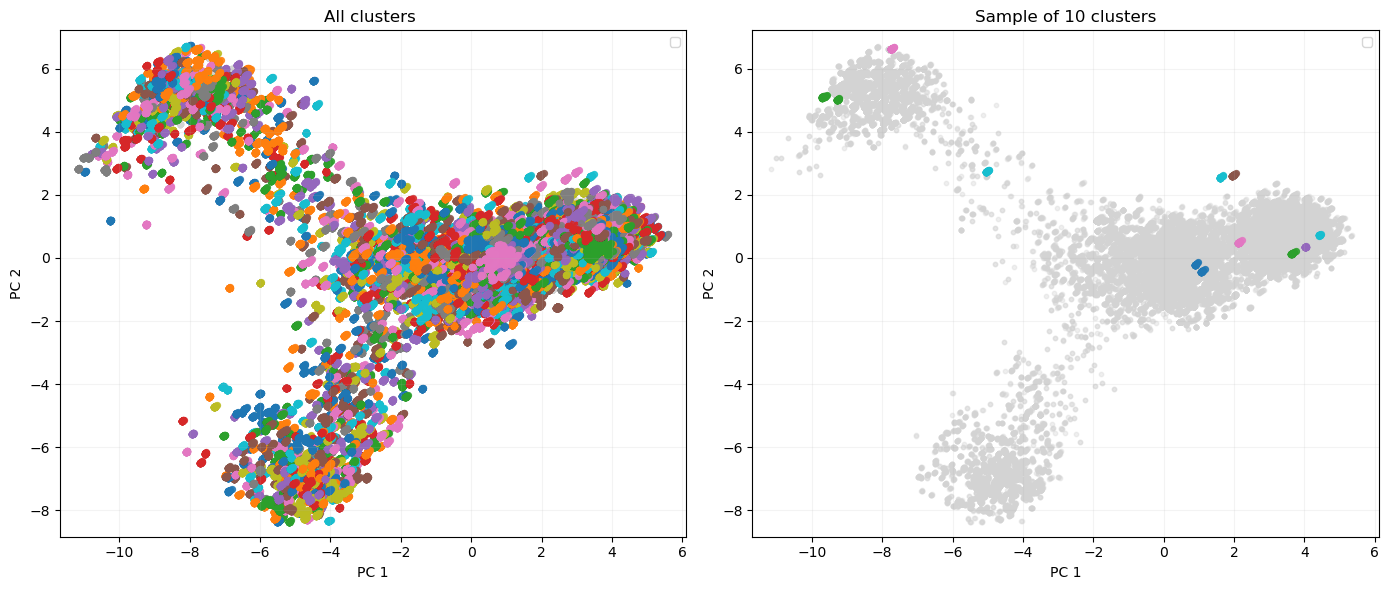

In [ ]:
import numpy as np
import matplotlib.pyplot as plt





# parameters
cluster_col = "cluster"
seed = 42
sample_n = 10 

rng = np.random.default_rng(seed)

# masks
noise_mask = labels == -1
non_noise_mask = ~noise_mask


unique_clusters = np.unique(labels[non_noise_mask]) if non_noise_mask.any() else np.array([])

# consistent colormap across panels
cmap = plt.get_cmap("tab10")
cluster_colors = {cluster: cmap(i % 10) for i, cluster in enumerate(unique_clusters)}


if unique_clusters.size == 0:
    sampled_clusters = np.array([], dtype=unique_clusters.dtype)
else:
    
    if unique_clusters.size <= sample_n:
        sampled_clusters = unique_clusters
    else:
        sampled_clusters = rng.choice(unique_clusters, size=sample_n, replace=False)


xmin, xmax = X_pca[:, 0].min(), X_pca[:, 0].max()
ymin, ymax = X_pca[:, 1].min(), X_pca[:, 1].max()
pad_x = (xmax - xmin) * 0.03
pad_y = (ymax - ymin) * 0.03
xlim = (xmin - pad_x, xmax + pad_x)
ylim = (ymin - pad_y, ymax + pad_y)

plt.figure(figsize=(14, 6))

# ---------- Left subplot: All clusters ----------
ax1 = plt.subplot(1, 2, 1)

if noise_mask.any():
    ax1.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                s=10, alpha=0.35, color="lightgray")


for cluster in unique_clusters:
    mask = labels == cluster
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=18, alpha=0.85, color=cluster_colors[cluster])

ax1.set_title("All clusters ")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")

if noise_mask.any():
    ax1.legend(markerscale=1.0, loc="best", fontsize=9, frameon=True)
ax1.grid(alpha=0.15)
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)

# ---------- Right subplot: Sampled clusters ----------
ax2 = plt.subplot(1, 2, 2)


if noise_mask.any():
    ax2.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                s=10, alpha=0.35, color="lightgray")


for cluster in sampled_clusters:
    mask = labels == cluster
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=18, alpha=0.85, color=cluster_colors[cluster])

ax2.set_title(f"Sample of {len(sampled_clusters)} clusters")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
if noise_mask.any():
    ax2.legend(markerscale=1.0, loc="best", fontsize=9, frameon=True)
ax2.grid(alpha=0.15)
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)

plt.tight_layout()
plt.show()


df shape: (275184, 88)


,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,motorcycle,taxi,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster
0,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1082
1,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,1082
2,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,1082
3,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1082
4,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,1082


/var/folders/p1/cwzgr9lj7_5ct_l3lyn4cd3r0000gn/T/ipykernel_6664/541415718.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


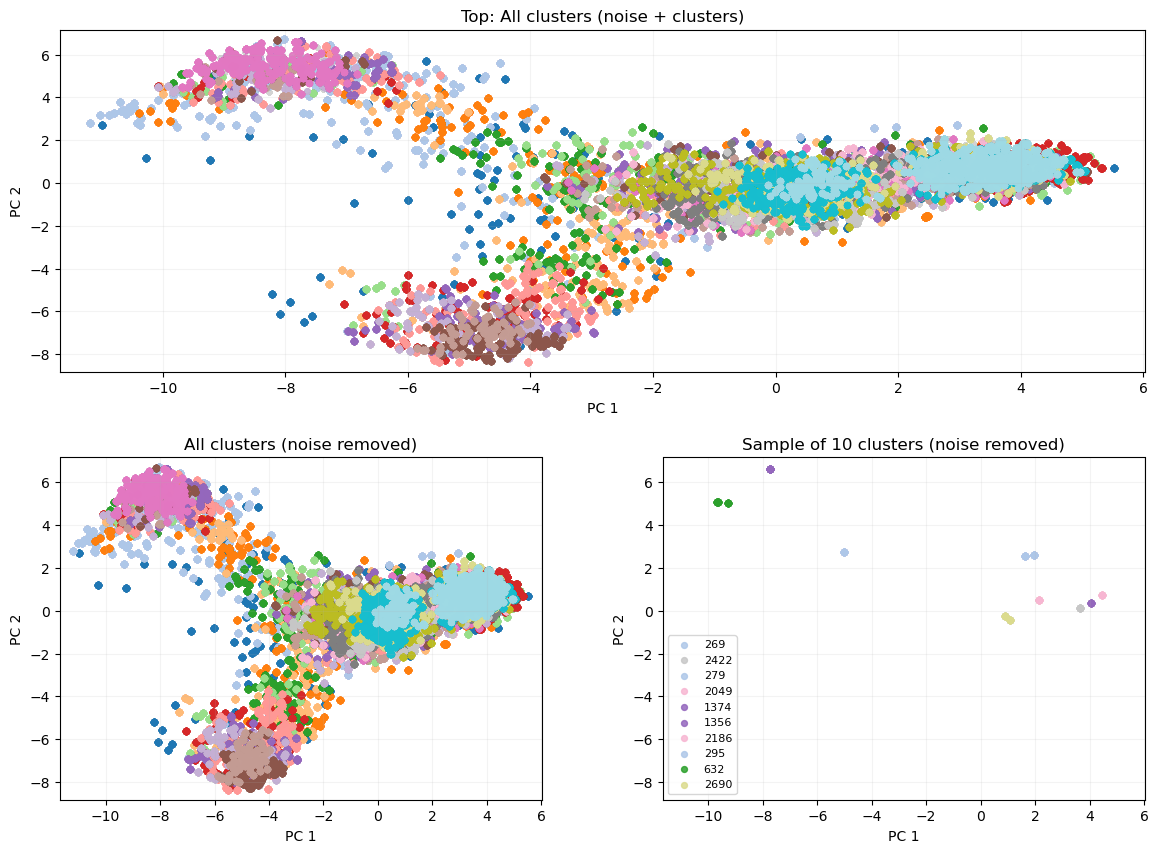

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


input_path = "/Users/athmiha/Desktop/final report/train_clusters.csv"
df = pd.read_csv(input_path)
print("df shape:", df.shape) 
display(df.head(5))


cluster_col = "cluster"
exclude_cols = {"start_interval", "entries", "excluded_roadway_entries", cluster_col}
seed = 42
sample_n = 10

# --- features: numeric only, excluding specified columns ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]
if len(feature_cols) == 0:
    raise ValueError("No numeric feature columns found for PCA (after exclusions).")

# --- build PCA input, drop rows with missing features (or impute instead) ---
X = df[feature_cols].dropna(axis=0, how="any")
valid_idx = X.index

# --- scale & reduce ---
X_scaled = StandardScaler().fit_transform(X.values)
X_pca = PCA(n_components=2, random_state=0).fit_transform(X_scaled)


labels = pd.to_numeric(df.loc[valid_idx, cluster_col], errors="coerce").fillna(-1).astype(int).values

# masks for convenience
noise_mask = labels == -1
non_noise_mask = ~noise_mask

unique_clusters = np.unique(labels[non_noise_mask]) if non_noise_mask.any() else np.array([])
n_colors = max(len(unique_clusters), 1)
cmap = plt.get_cmap("tab20", n_colors)
cluster_to_idx = {cluster: i for i, cluster in enumerate(unique_clusters)}
cluster_colors = {cluster: cmap(cluster_to_idx[cluster] % n_colors) for cluster in unique_clusters}


rng = np.random.default_rng(seed)
if unique_clusters.size == 0:
    sampled_clusters = np.array([], dtype=unique_clusters.dtype)
else:
    sampled_clusters = unique_clusters if unique_clusters.size <= sample_n else rng.choice(unique_clusters, size=sample_n, replace=False)

# axis limits shared
xmin, xmax = X_pca[:, 0].min(), X_pca[:, 0].max()
ymin, ymax = X_pca[:, 1].min(), X_pca[:, 1].max()
pad_x = (xmax - xmin) * 0.03
pad_y = (ymax - ymin) * 0.03
xlim = (xmin - pad_x, xmax + pad_x)
ylim = (ymin - pad_y, ymax + pad_y)

# ----------------- Plot layout -----------------
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.0], hspace=0.25, wspace=0.25)

# Top: full-width, everything (noise + clusters)
ax_top = fig.add_subplot(gs[0, :])

if noise_mask.any():
    ax_top.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                   s=10, alpha=0.35, color="lightgray", label="Noise (-1)")
# plot each non-noise cluster (use mapped colors)
for cluster in unique_clusters:
    mask = labels == cluster
    ax_top.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=18, alpha=0.85, color=cluster_colors[cluster], label=str(cluster))
ax_top.set_title("Top: All clusters (noise + clusters)")
ax_top.set_xlabel("PC 1"); ax_top.set_ylabel("PC 2")
ax_top.set_xlim(xlim); ax_top.set_ylim(ylim)
ax_top.grid(alpha=0.15)

if unique_clusters.size <= 25:
    ax_top.legend(ncol=2, fontsize=8, markerscale=1.0, loc="best")

# Bottom-left: all clusters but NOISE (drop noise)
ax_bl = fig.add_subplot(gs[1, 0])
for cluster in unique_clusters:
    mask = labels == cluster
    ax_bl.scatter(X_pca[mask, 0], X_pca[mask, 1],
                  s=18, alpha=0.85, color=cluster_colors[cluster])
ax_bl.set_title("All clusters (noise removed)")
ax_bl.set_xlabel("PC 1"); ax_bl.set_ylabel("PC 2")
ax_bl.set_xlim(xlim); ax_bl.set_ylim(ylim)
ax_bl.grid(alpha=0.15)

# Bottom-right: sampled clusters (noise removed)
ax_br = fig.add_subplot(gs[1, 1])
for cluster in sampled_clusters:
    mask = labels == cluster
    ax_br.scatter(X_pca[mask, 0], X_pca[mask, 1],
                  s=18, alpha=0.85, color=cluster_colors[cluster], label=str(cluster))
ax_br.set_title(f"Sample of {len(sampled_clusters)} clusters (noise removed)")
ax_br.set_xlabel("PC 1"); ax_br.set_ylabel("PC 2")
ax_br.set_xlim(xlim); ax_br.set_ylim(ylim)
ax_br.grid(alpha=0.15)
if len(sampled_clusters) > 0 and len(sampled_clusters) <= 25:
    ax_br.legend(ncol=1, fontsize=8, markerscale=1.0, loc="best")

plt.tight_layout()
plt.show()


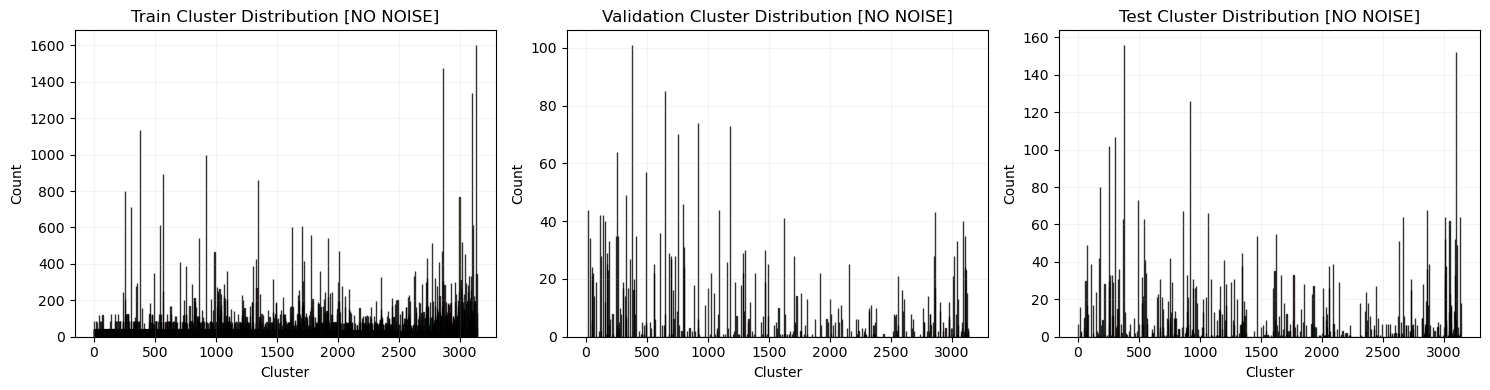

In [ ]:
# charts for teh cluster distibutions in train test and val set
train_path = f"/Users/athmiha/Desktop/final report/train_clusters.csv"
test_path = f"/Users/athmiha/Desktop/final report/test_clusters.csv"
val_path = f"/Users/athmiha/Desktop/final report/val_clusters.csv"


df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)
df_val   = pd.read_csv(val_path)

# --- Drop noise clusters (-1) ---
df_train = df_train[df_train[cluster_col] != -1]
df_test  = df_test[df_test[cluster_col]  != -1]
df_val   = df_val[df_val[cluster_col]   != -1]

all_clusters = np.unique(
    np.concatenate([
        df_train[cluster_col].unique(),
        df_val[cluster_col].unique(),
        df_test[cluster_col].unique()
    ])
)


cmap = plt.get_cmap("tab20")  # lowk not working
cluster_colors = {cluster: cmap(i % 20) for i, cluster in enumerate(sorted(all_clusters))}

bins = np.arange(all_clusters.min() - 0.5, all_clusters.max() + 1.5, 1)


plt.figure(figsize=(15, 4))

def plot_histogram(ax, df, title):
    counts = [ (df[cluster_col] == cluster).sum() for cluster in sorted(all_clusters) ]
    colors = [ cluster_colors[cluster] for cluster in sorted(all_clusters) ]
    ax.bar(sorted(all_clusters), counts, color=colors, edgecolor="black", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.15)

# Train
ax1 = plt.subplot(1, 3, 1)
plot_histogram(ax1, df_train, "Train Cluster Distribution [NO NOISE]")

# Validation
ax2 = plt.subplot(1, 3, 2)
plot_histogram(ax2, df_val, "Validation Cluster Distribution [NO NOISE]")

# Test
ax3 = plt.subplot(1, 3, 3)
plot_histogram(ax3, df_test, "Test Cluster Distribution [NO NOISE]")

plt.tight_layout()
plt.show()

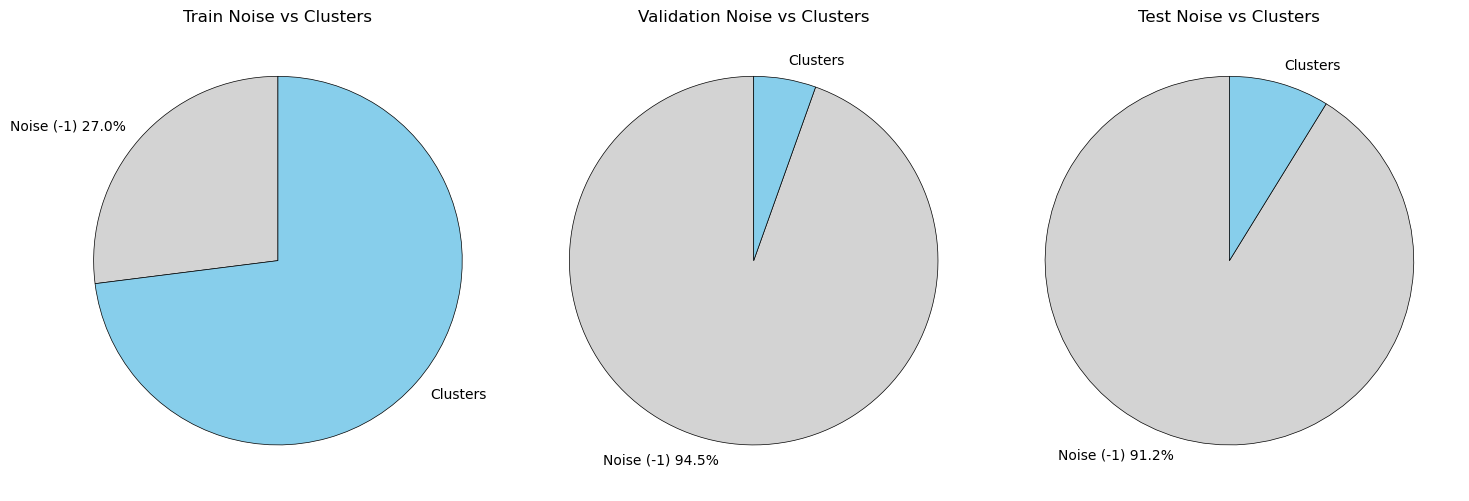

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data ---
train_path = "/Users/athmiha/Desktop/final report/train_clusters.csv"
test_path  = "/Users/athmiha/Desktop/final report/test_clusters.csv"
val_path   = "/Users/athmiha/Desktop/final report/val_clusters.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)
df_val   = pd.read_csv(val_path)

cluster_col = "cluster"  

def get_pie_data(df, cluster_col="cluster"):
    total = len(df)
    noise_count = (df[cluster_col] == -1).sum()
    cluster_count = total - noise_count
    sizes = [noise_count, cluster_count]
    labels = [f"Noise (-1) {noise_count/total:.1%}", "Clusters"]
    colors = ["lightgray", "skyblue"]
    return sizes, labels, colors


plt.figure(figsize=(15, 5))

for i, (df, title) in enumerate(zip([df_train, df_val, df_test],
                                    ["Train", "Validation", "Test"]), start=1):
    sizes, labels, colors = get_pie_data(df, cluster_col)
    plt.subplot(1, 3, i)
    plt.pie(sizes, labels=labels, colors=colors, startangle=90, autopct=None,
            wedgeprops=dict(edgecolor='k', linewidth=0.5))
    plt.title(f"{title} Noise vs Clusters")
    
plt.tight_layout()
plt.show()
